In [ ]:
#!pip uninstall xgboost

In [1]:
!pip install optuna xgboost==3.1.1 lightgbm fastparquet imbalanced-learn torch rapidfuzz


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 MB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.7/404.7 kB 25.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 68.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 74.8 MB/s eta 0:00:00
  Attempting uninstall: xgboost
    Found existing installation: xgboost 3.1.2
    Uninstalling xgboost-3.1.2:
      Successfully uninstalled xgboost-3.1.2


In [2]:
import numpy as np
import pandas as pd
import os, joblib,time


from sklearn.model_selection import StratifiedKFold, cross_val_score,train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.calibration import CalibratedClassifierCV

import optuna
from optuna.pruners import SuccessiveHalvingPruner
from optuna.exceptions import TrialPruned

#from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.impute import SimpleImputer
from functools import partial
from sklearn.calibration import calibration_curve

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, matthews_corrcoef,
    cohen_kappa_score, balanced_accuracy_score,
    classification_report, brier_score_loss, log_loss,
    confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve, RocCurveDisplay,roc_curve,auc
)

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

import matplotlib.pyplot as plt
import seaborn as sns

import subprocess
import xgboost as xgb
import lightgbm as lgb
import torch

import re
from rapidfuzz import fuzz, process

import warnings
warnings.filterwarnings('ignore')

### Carregando base de dados

In [15]:
df =pd.read_parquet('df_lept_atlas.parquet',engine='fastparquet')




### Selecionar variáveis relevantes para triagem


In [16]:
df.columns

Index(['id_municipio', 'nu_idade_n', 'cs_sexo', 'cs_gestant', 'cs_raca',
       'cs_escol_n', 'sg_uf', 'id_ocupa_n', 'ant_cb_lam', 'ant_cb_cri',
       'ant_cb_sin', 'ant_cb_cor', 'ant_cb_roe', 'ant_cb_ter', 'ant_cb_lix',
       'ant_cb_out', 'ant_humano', 'ant_animai', 'cli_febre', 'cli_mialgi',
       'cli_cefale', 'cli_prost', 'cli_conges', 'cli_pantur', 'cli_vomito',
       'cli_diarre', 'cli_icteri', 'cli_renal', 'cli_respir', 'cli_cardia',
       'cli_hemopu', 'cli_hemorr', 'cli_mening', 'cli_outros', 'classi_fin',
       'con_area', 'con_ambien', 'baixa_escolaridade', 'raca_vulneravel',
       'faixa_vulneravel', 'vulnerabilidade_social', 'nivel_vulnerabilidade',
       'mes_sintomas', 'estacao', 'periodo_chuvoso', 'expectativa_vida',
       'fecundidade_total', 'prob_sobrevivencia_40', 'prob_sobrevivencia_60',
       'taxa_freq_bruta_basico', 'taxa_freq_bruta_fundamental',
       'taxa_freq_bruta_medio', 'taxa_freq_liquida_superior',
       'prop_pobreza_extrema', 'prop_vulner_

In [17]:

triage_features = ['id_municipio', 'nu_idade_n', 'cs_sexo', 'cs_gestant', 'cs_raca',
       'cs_escol_n', 'sg_uf', 'id_ocupa_n', 'ant_cb_lam', 'ant_cb_cri',
       'ant_cb_sin', 'ant_cb_cor', 'ant_cb_roe', 'ant_cb_ter',
       'ant_cb_lix', 'ant_cb_out', 'ant_humano', 'ant_animai',
       'cli_febre', 'cli_mialgi', 'cli_cefale', 'cli_prost', 'cli_conges',
       'cli_pantur', 'cli_vomito', 'cli_diarre', 'cli_icteri',
       'cli_renal', 'cli_respir', 'cli_cardia', 'cli_hemopu',
       'cli_hemorr', 'cli_mening', 'cli_outros', 'con_area', 'con_ambien',
       'baixa_escolaridade', 'raca_vulneravel', 'faixa_vulneravel',
       'vulnerabilidade_social', 'nivel_vulnerabilidade', 'mes_sintomas',
       'estacao', 'periodo_chuvoso', 'expectativa_vida',
       'fecundidade_total', 'prob_sobrevivencia_40',
       'prob_sobrevivencia_60', 'taxa_freq_bruta_basico',
       'taxa_freq_bruta_fundamental', 'taxa_freq_bruta_medio',
       'taxa_freq_liquida_superior', 'prop_pobreza_extrema',
       'prop_vulner_pobreza', 'taxa_agua_encanada',
       'taxa_banheiro_agua_encanada', 'taxa_coleta_lixo',
       'taxa_energia_eletrica', 'taxa_agua_esgoto_inadequados',
       'taxa_paredes_inadequados', 'populacao', 'indice_escolaridade',
       'indice_frequencia_escolar', 'idhm', 'idhm_e', 'idhm_l', 'idhm_r']


target_col = 'classi_fin'  # rótulo: confirmado vs descartado

if target_col == 'classi_fin':
    df = df[df['classi_fin'].isin(['Confirmado', 'Descartado'])].copy()

    # Criar variável alvo binária
    df['alvo'] = df['classi_fin'].map({
        'Confirmado': 1,
        'Descartado': 0
    })

## Amostragem estratificada
amostragem = df.groupby("alvo").sample(frac=0.05, random_state=42).copy()

X_data=amostragem[triage_features]
y_data = amostragem['alvo']


## Train framework

### Funções de apoio

In [18]:


def detect_gpu():
    """
    Detecta corretamente suporte a GPU para CUDA, XGBoost e LightGBM.
    Retorna um dicionário completo.
    """

    # 1. Verificar CUDA geral
    try:
        cuda_available = torch.cuda.is_available()
    except:
        cuda_available = False


    # 2. Testar LightGBM GPU

    try:
        # Testa se LightGBM foi compilado com suporte a GPU
        lgb_gpu = lgb.register_logger(lambda x: x)  # dummy
        booster = lgb.LGBMClassifier(device="gpu")
        lgb_gpu = True
    except:
        lgb_gpu = False


    # 3. Detalhes da GPU via nvidia-smi

    try:
        smi_output = subprocess.check_output("nvidia-smi", shell=True).decode()
        gpu_info = smi_output.split("\n")[2].strip()
    except:
        gpu_info = "Nenhuma GPU detectada (nvidia-smi não disponível)"

    return {
        "cuda_available": cuda_available,
        "lightgbm_gpu": lgb_gpu,
        "gpu_info": gpu_info
    }


In [19]:
def get_model_params_gpu(model_name, gpu_info):
    """
    Retorna hiperparâmetros base apropriados para CPU ou GPU.
    """
    use_gpu = gpu_info["cuda_available"]

    if model_name == "xgboost":
        if use_gpu:
            return {
                "tree_method": "gpu_hist",
                "predictor": "gpu_predictor"
            }
        else:
            return {
                "tree_method": "hist",
                "predictor": "cpu_predictor"
            }

    elif model_name == "lightgbm":
        if use_gpu:
            return {
                "device": "gpu",
                "gpu_platform_id": 0,
                "gpu_device_id": 0
            }
        else:
            return {
                "device": "cpu"
            }

    elif model_name in ["random_forest", "svm"]:
        # sklearn não usa GPU
        return {}

    return {}


In [20]:
def get_feature_types(df):
    """
    Identifica automaticamente colunas categóricas e numéricas de um dataframe.

    Retorna:
        cat_cols  -> lista de colunas categóricas
        num_cols  -> lista de colunas numéricas
    """

    # CATEGÓRICAS: object, category ou boolean
    cat_cols = df.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()

    # NUMÉRICAS: int, float
    num_cols = df.select_dtypes(include=['int', 'float', 'int64', 'float64']).columns.tolist()

    return cat_cols, num_cols


###  1. FUNÇÃO PARA CRIAR O MODELO A PARTIR DO TRIAL (Optuna)

In [21]:
def create_model(trial, gpu_info):
    model_name = trial.suggest_categorical(
        "model_name", ["svm","xgboost", "lightgbm", "random_forest"]
    )

    gpu_params = get_model_params_gpu(model_name, gpu_info)

    # RANDOM FOREST
    if model_name == "random_forest":
        return RandomForestClassifier(
            n_estimators=trial.suggest_int("n_estimators", 5, 30),
            max_depth=trial.suggest_int("max_depth", 3, 9),
            min_samples_split=trial.suggest_int("min_samples_split", 2, 10),
            min_samples_leaf=trial.suggest_int("min_samples_leaf", 1, 5),
            random_state=42,
            class_weight= 'balanced',
            **gpu_params
        )

    # SVM
    elif model_name == "svm":
        svm= LinearSVC(
            C=trial.suggest_float("C", 0.1, 3.0),
            max_iter=5000,
            class_weight= 'balanced'
        )
        return CalibratedClassifierCV(svm, method="sigmoid")

    # XGBOOST
    elif model_name == "xgboost":
        return XGBClassifier(
            n_estimators=trial.suggest_int("n_estimators", 5, 30),
            max_depth=trial.suggest_int("max_depth", 3, 9),
            learning_rate=trial.suggest_float("learning_rate", 0.01, 0.3),
            subsample=trial.suggest_float("subsample", 0.5, 1.0),
            colsample_bytree=trial.suggest_float("colsample_bytree", 0.5, 1.0),
            eval_metric="logloss",
            random_state=42,
            class_weight= 'balanced',
            n_jobs=-1,
            #**gpu_params
        )

    # LIGHTGBM
    elif model_name == "lightgbm":
        return LGBMClassifier(
            n_estimators=trial.suggest_int("n_estimators", 5, 30),
            learning_rate=trial.suggest_float("learning_rate", 0.01, 0.3),
            max_depth=trial.suggest_int("max_depth", 3, 9),
            subsample=trial.suggest_float("subsample", 0.5, 1.0),
            colsample_bytree=trial.suggest_float("colsample_bytree", 0.5, 1.0),
            random_state=42,
            is_unbalance=True,
           force_col_wise=True,
            **gpu_params
        )


### 2. FUNÇÃO OBJETIVO DO OPTUNA (COM CROSS-VALIDATION)


In [22]:
def build_pipeline(model, cat_cols, num_cols):

    # construindo o preprocessor
    num_preprocessor = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    cat_preprocessor = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown='infrequent_if_exist'))
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", num_preprocessor, num_cols),
            ("cat", cat_preprocessor, cat_cols)
        ]
    )

    # construindo pipe
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("smote", SMOTE(random_state=42)),
        ("model", model)
    ])

    return pipe


In [23]:
def objective(trial, X_train, y_train, cat_cols, num_cols,feature_names, gpu_info):

    model = create_model(trial, gpu_info)

    pipe = build_pipeline(model ,cat_cols, num_cols)


    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

    scores = []
    for step, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train)):

        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]


        pipe.fit(X_tr, y_tr)
        fold_auc = roc_auc_score(y_val, pipe.predict_proba(X_val)[:, 1])
        scores.append(fold_auc)

        #  reporta o valor parcial ao Optuna
        trial.report(fold_auc, step=step)

        #  aborta a tentativa dado a avaliação do pruner
        if trial.should_prune():
            raise TrialPruned()


    return np.mean(scores)


In [24]:
# salva os logs das tentativas com métricas, tempo de treinamento, e parametros utilizados pelos modelos
def dump_trials(study, trial):
    df_metrics = study.trials_dataframe(attrs=("number", "value", "params", "state","duration"))
    df_metrics.to_csv("log_opt/trials_log_v2.csv", index=False)


### 3. VALIDAÇÃO EXTERNA (OUTER CV) + OPTUNA INTERNO


In [25]:
def outer_cv_training_with_results(
    X, y, cat_cols, num_cols, n_trials=30, n_splits=5
):

    gpu_info = detect_gpu()
    print("\n🔍 GPU detectada:", gpu_info)

    outer_cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    results = []
    feature_names = X.columns
    fold = 1
    for train_idx, test_idx in outer_cv.split(X, y):

        print(f"\n==============================")
        print(f"  Fold Externo {fold}/{n_splits}")
        print(f"==============================")

        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        pruner = SuccessiveHalvingPruner(min_resource=1,
                                 reduction_factor=3,
                                 min_early_stopping_rate=1)

        study = optuna.create_study(direction="maximize")

        objective_fixed = partial(objective,
                          X_train=X_train,
                          y_train=y_train,
                          cat_cols=cat_cols,
                          num_cols=num_cols,
                          feature_names=feature_names,
                          gpu_info=gpu_info)

        study.optimize(objective_fixed,
                      n_trials=n_trials,
                      callbacks=[dump_trials],
                      timeout=1800,
                      n_jobs=-1,
                      )

        best_params = study.best_params
        best_model_name = best_params["model_name"]
        best_model = create_model(study.best_trial, gpu_info)


        pipe = build_pipeline(best_model ,cat_cols, num_cols)

        # treino com timer
        start_time = time.time()
        pipe.fit(X_train, y_train)
        train_time = time.time() - start_time

        # CHECKPOINT
        checkpoint_dir = "checkpoints_best_models"
        if not os.path.exists(checkpoint_dir):
            os.makedirs(checkpoint_dir)

        checkpoint_path = os.path.join(
            checkpoint_dir, f"best_model_fold_{fold}.pkl"
        )
        joblib.dump(pipe, checkpoint_path)

        # predição
        y_pred = pipe.predict(X_test)
        y_pred_prob = pipe.predict_proba(X_test)[:, 1]

        # métricas
        auc = roc_auc_score(y_test, y_pred_prob)
        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        rec = recall_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred)

        # salvar dados do fold
        results.append({
            "fold": fold,
            "best_model": best_model_name,
            "auc": auc,
            "accuracy": acc,
            "f1": f1,
            "recall": rec,
            "precision": prec,
            "hyperparameters": best_params,
            "checkpoint_path": checkpoint_path,
            "train_time_seconds": train_time,
            #"test_data": {
            #    "X_test": X_test.copy(),
            #    "y_test": y_test.reset_index(drop=True),
            #    "y_pred": pd.Series(y_pred)
            #}
        })

        fold += 1

    return results


# Execute Framework

In [26]:
# ================================================
# CRIA DIRETÓRIO DE CHECKPOINTS (se não existir)
# ================================================
import os, joblib
checkpoint_dir = "checkpoints_best_models"

if not os.path.exists(checkpoint_dir):
    os.makedirs(checkpoint_dir)

checkpoint_dir = "log_opt"
if not os.path.exists(checkpoint_dir):
    os.makedirs(checkpoint_dir)


# ================================================


In [27]:
cat_cols, num_cols = get_feature_types(X_data)
df_results = outer_cv_training_with_results(
    X_data, y_data,
    cat_cols=cat_cols,
    num_cols=num_cols,
    n_trials=30,
    n_splits=5
)


[I 2025-12-08 02:50:12,949] A new study created in memory with name: no-name-1f064c2c-442f-46e7-a4c4-8bdbe0563d89



🔍 GPU detectada: {'cuda_available': False, 'lightgbm_gpu': False, 'gpu_info': 'Nenhuma GPU detectada (nvidia-smi não disponível)'}

  Fold Externo 1/5


[I 2025-12-08 02:50:15,518] Trial 0 finished with value: 0.877089679571785 and parameters: {'model_name': 'random_forest', 'n_estimators': 9, 'max_depth': 5, 'min_samples_split': 10, 'min_samples_leaf': 5}. Best is trial 0 with value: 0.877089679571785.
[I 2025-12-08 02:50:18,195] Trial 2 finished with value: 0.9297662177141293 and parameters: {'model_name': 'lightgbm', 'n_estimators': 20, 'learning_rate': 0.25080352319157057, 'max_depth': 3, 'subsample': 0.854653019858217, 'colsample_bytree': 0.6573648660611067}. Best is trial 2 with value: 0.9297662177141293.
[I 2025-12-08 02:50:24,751] Trial 1 finished with value: 0.9262812526926427 and parameters: {'model_name': 'xgboost', 'n_estimators': 22, 'max_depth': 7, 'learning_rate': 0.07252330843916083, 'subsample': 0.5926556753766443, 'colsample_bytree': 0.9592237863347167}. Best is trial 2 with value: 0.9297662177141293.
[I 2025-12-08 02:50:31,828] Trial 3 finished with value: 0.9039035436529502 and parameters: {'model_name': 'svm', 'C':

[LightGBM] [Info] Number of positive: 5032, number of negative: 5032
[LightGBM] [Info] Total Bins 32046
[LightGBM] [Info] Number of data points in the train set: 10064, number of used features: 219
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with posi

[I 2025-12-08 02:51:02,918] A new study created in memory with name: no-name-96c5f20d-4532-44d7-9a76-2784369f71c0


...

[LightGBM] [Info] Number of positive: 5032, number of negative: 5032
[LightGBM] [Info] Total Bins 32193
[LightGBM] [Info] Number of data points in the train set: 10064, number of used features: 213
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


[I 2025-12-08 02:53:39,436] A new study created in memory with name: no-name-9eb573a6-c88a-4a37-9667-a899e2e1a78d



  Fold Externo 5/5


[I 2025-12-08 02:53:42,234] Trial 1 finished with value: 0.9156229917785758 and parameters: {'model_name': 'lightgbm', 'n_estimators': 10, 'learning_rate': 0.14238482612463485, 'max_depth': 3, 'subsample': 0.8389046596313314, 'colsample_bytree': 0.8013314452057849}. Best is trial 1 with value: 0.9156229917785758.
[I 2025-12-08 02:53:50,252] Trial 0 finished with value: 0.9104303039838485 and parameters: {'model_name': 'svm', 'C': 2.1047084644348018}. Best is trial 1 with value: 0.9156229917785758.
[I 2025-12-08 02:53:53,214] Trial 2 finished with value: 0.9105192220488648 and parameters: {'model_name': 'svm', 'C': 1.9659761118286065}. Best is trial 1 with value: 0.9156229917785758.
[I 2025-12-08 02:53:59,141] Trial 3 finished with value: 0.9059411852523529 and parameters: {'model_name': 'xgboost', 'n_estimators': 23, 'max_depth': 7, 'learning_rate': 0.03469035736451792, 'subsample': 0.9380565968957606, 'colsample_bytree': 0.9275723580394767}. Best is trial 1 with value: 0.9156229917785

[LightGBM] [Info] Number of positive: 5032, number of negative: 5032
[LightGBM] [Info] Total Bins 32510
[LightGBM] [Info] Number of data points in the train set: 10064, number of used features: 220
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with posi

#### Conferir checkpoints intermediarios

In [28]:
df_results=pd.DataFrame(df_results)

In [29]:
df_results.to_parquet('df_results.parquet')

In [30]:
df_metrics = pd.read_csv('log_opt/trials_log_v2.csv')
display(df_metrics)


,number,value,params_C,params_colsample_bytree,params_learning_rate,params_max_depth,params_min_samples_leaf,params_min_samples_split,params_model_name,params_n_estimators,params_subsample,state,duration
0,0,0.910430,2.104708,NaN,NaN,NaN,NaN,NaN,svm,NaN,NaN,COMPLETE,0 days 00:00:10.808315
1,1,0.915623,NaN,0.801331,0.142385,3.0,NaN,NaN,lightgbm,10.0,0.838905,COMPLETE,0 days 00:00:02.786003
2,2,0.910519,1.965976,NaN,NaN,NaN,NaN,NaN,svm,NaN,NaN,COMPLETE,0 days 00:00:10.969289
3,3,0.905941,NaN,0.927572,0.034690,7.0,NaN,NaN,xgboost,23.0,0.938057,COMPLETE,0 days 00:00:08.875986
4,4,0.910394,2.160309,NaN,NaN,NaN,NaN,NaN,svm,NaN,NaN,COMPLETE,0 days 00:00:10.123704
5,5,0.896426,NaN,NaN,NaN,3.0,5.0,9.0,random_forest,15.0,NaN,COMPLETE,0 days 00:00:01.998935
6,6,0.924238,NaN,0.831182,0.109377,6.0,NaN,NaN,lightgbm,19.0,0.958474,COMPLETE,0 days 00:00:03.001261
7,7,0.904468,NaN,0.833155,0.109921,7.0,NaN,NaN,xgboost,5.0,0.972424,PRUNED,0 days 00:00:01.019491
8,8,0.860768,NaN,0.629464,0.032521,4.0,NaN,NaN,xgboost,18.0,0.902481,PRUNED,0 days 00:00:01.698765
9,9,0.920459,NaN,0.717804,0.124305,3.0,NaN,NaN,xgboost,27.0,0.833607,COMPLETE,0 days 00:00:04.426358


Carregando o pkl

In [31]:
import joblib

modelo = joblib.load("checkpoints_best_models/best_model_fold_1.pkl")


In [32]:
modelo

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['id_municipio', 'nu_idade_n',
                                                   'baixa_escolaridade',
                                                   'raca_vulneravel',
                                                   'faixa_vulneravel',
                                                   'vulnerabilidade_social',
                                                   'mes_sintomas',
                                                   'periodo_chuvoso',
                                                   'expectativa_vida',
                                                   'fecundidade_total',
                                                   'pro...
                                                   'cli_vomito', 'cli_diarre',
                                                   'cli_icteri', 'cli_renal',
                                                   'cli_respir', 'cli_cardia',
                                                   'cli_hemopu', 'cli_hemorr', ...])])),
                ('smote', SMOTE(random_state=42)),
                ('model',
                 LGBMClassifier(colsample_bytree=0.9961178975410104,
                                device='cpu', force_col_wise=True,
                                is_unbalance=True,
                                learning_rate=0.165025969898394, max_depth=5,
                                n_estimators=27, random_state=42,
                                subsample=0.7878582513758825))])

In [33]:
modelo.named_steps["preprocessor"].get_feature_names_out()

array(['num__id_municipio', 'num__nu_idade_n', 'num__baixa_escolaridade',
       'num__raca_vulneravel', 'num__faixa_vulneravel',
       'num__vulnerabilidade_social', 'num__mes_sintomas',
       'num__periodo_chuvoso', 'num__expectativa_vida',
       'num__fecundidade_total', 'num__prob_sobrevivencia_40',
       'num__prob_sobrevivencia_60', 'num__taxa_freq_bruta_basico',
       'num__taxa_freq_bruta_fundamental', 'num__taxa_freq_bruta_medio',
       'num__taxa_freq_liquida_superior', 'num__prop_pobreza_extrema',
       'num__prop_vulner_pobreza', 'num__taxa_agua_encanada',
       'num__taxa_banheiro_agua_encanada', 'num__taxa_coleta_lixo',
       'num__taxa_energia_eletrica', 'num__taxa_agua_esgoto_inadequados',
       'num__taxa_paredes_inadequados', 'num__populacao',
       'num__indice_escolaridade', 'num__indice_frequencia_escolar',
       'num__idhm', 'num__idhm_e', 'num__idhm_l', 'num__idhm_r',
       'cat__cs_sexo_Feminino', 'cat__cs_sexo_Masculino',
       'cat__cs_gestant_1º

In [34]:
modelo.predict(X_data.iloc[-10:])

array([0, 1, 1, 1, 1, 1, 1, 1, 0, 1])

## Avaliando modelo

In [35]:
# 2. Basic overview
print("=== Shape of DataFrame ===")
print(df_metrics.shape)

display(df_metrics)


=== Shape of DataFrame ===
(30, 13)


,number,value,params_C,params_colsample_bytree,params_learning_rate,params_max_depth,params_min_samples_leaf,params_min_samples_split,params_model_name,params_n_estimators,params_subsample,state,duration
0,0,0.910430,2.104708,NaN,NaN,NaN,NaN,NaN,svm,NaN,NaN,COMPLETE,0 days 00:00:10.808315
1,1,0.915623,NaN,0.801331,0.142385,3.0,NaN,NaN,lightgbm,10.0,0.838905,COMPLETE,0 days 00:00:02.786003
2,2,0.910519,1.965976,NaN,NaN,NaN,NaN,NaN,svm,NaN,NaN,COMPLETE,0 days 00:00:10.969289
3,3,0.905941,NaN,0.927572,0.034690,7.0,NaN,NaN,xgboost,23.0,0.938057,COMPLETE,0 days 00:00:08.875986
4,4,0.910394,2.160309,NaN,NaN,NaN,NaN,NaN,svm,NaN,NaN,COMPLETE,0 days 00:00:10.123704
5,5,0.896426,NaN,NaN,NaN,3.0,5.0,9.0,random_forest,15.0,NaN,COMPLETE,0 days 00:00:01.998935
6,6,0.924238,NaN,0.831182,0.109377,6.0,NaN,NaN,lightgbm,19.0,0.958474,COMPLETE,0 days 00:00:03.001261
7,7,0.904468,NaN,0.833155,0.109921,7.0,NaN,NaN,xgboost,5.0,0.972424,PRUNED,0 days 00:00:01.019491
8,8,0.860768,NaN,0.629464,0.032521,4.0,NaN,NaN,xgboost,18.0,0.902481,PRUNED,0 days 00:00:01.698765
9,9,0.920459,NaN,0.717804,0.124305,3.0,NaN,NaN,xgboost,27.0,0.833607,COMPLETE,0 days 00:00:04.426358


In [36]:
df_metrics

,number,value,params_C,params_colsample_bytree,params_learning_rate,params_max_depth,params_min_samples_leaf,params_min_samples_split,params_model_name,params_n_estimators,params_subsample,state,duration
0,0,0.910430,2.104708,NaN,NaN,NaN,NaN,NaN,svm,NaN,NaN,COMPLETE,0 days 00:00:10.808315
1,1,0.915623,NaN,0.801331,0.142385,3.0,NaN,NaN,lightgbm,10.0,0.838905,COMPLETE,0 days 00:00:02.786003
2,2,0.910519,1.965976,NaN,NaN,NaN,NaN,NaN,svm,NaN,NaN,COMPLETE,0 days 00:00:10.969289
3,3,0.905941,NaN,0.927572,0.034690,7.0,NaN,NaN,xgboost,23.0,0.938057,COMPLETE,0 days 00:00:08.875986
4,4,0.910394,2.160309,NaN,NaN,NaN,NaN,NaN,svm,NaN,NaN,COMPLETE,0 days 00:00:10.123704
5,5,0.896426,NaN,NaN,NaN,3.0,5.0,9.0,random_forest,15.0,NaN,COMPLETE,0 days 00:00:01.998935
6,6,0.924238,NaN,0.831182,0.109377,6.0,NaN,NaN,lightgbm,19.0,0.958474,COMPLETE,0 days 00:00:03.001261
7,7,0.904468,NaN,0.833155,0.109921,7.0,NaN,NaN,xgboost,5.0,0.972424,PRUNED,0 days 00:00:01.019491
8,8,0.860768,NaN,0.629464,0.032521,4.0,NaN,NaN,xgboost,18.0,0.902481,PRUNED,0 days 00:00:01.698765
9,9,0.920459,NaN,0.717804,0.124305,3.0,NaN,NaN,xgboost,27.0,0.833607,COMPLETE,0 days 00:00:04.426358


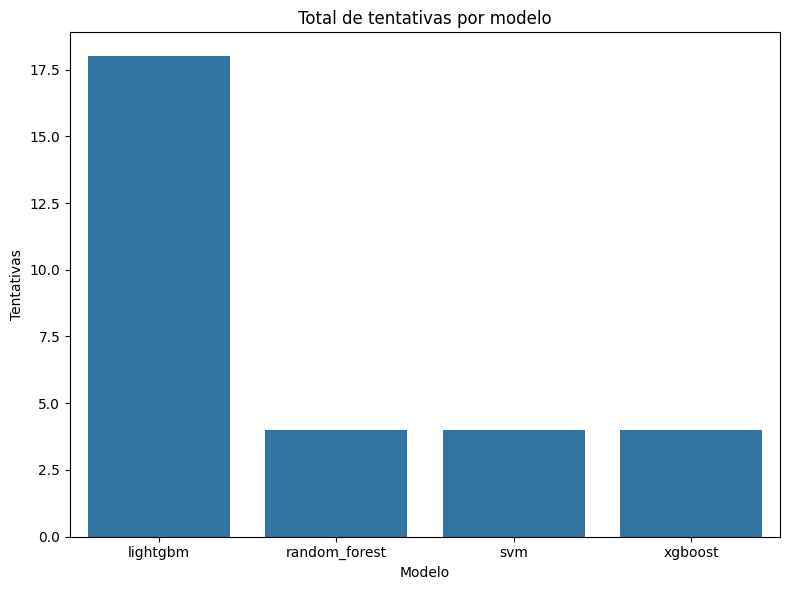

In [37]:
# Total de trials por modelo
total_trials = (df_metrics.groupby("params_model_name").size().reset_index(name="total_trials"))

plt.figure(figsize=(8, 6))
sns.barplot(data=total_trials,x="params_model_name",y="total_trials",)
plt.title("Total de tentativas por modelo")
plt.xlabel("Modelo")
plt.ylabel("Tentativas")
plt.tight_layout()
plt.show()

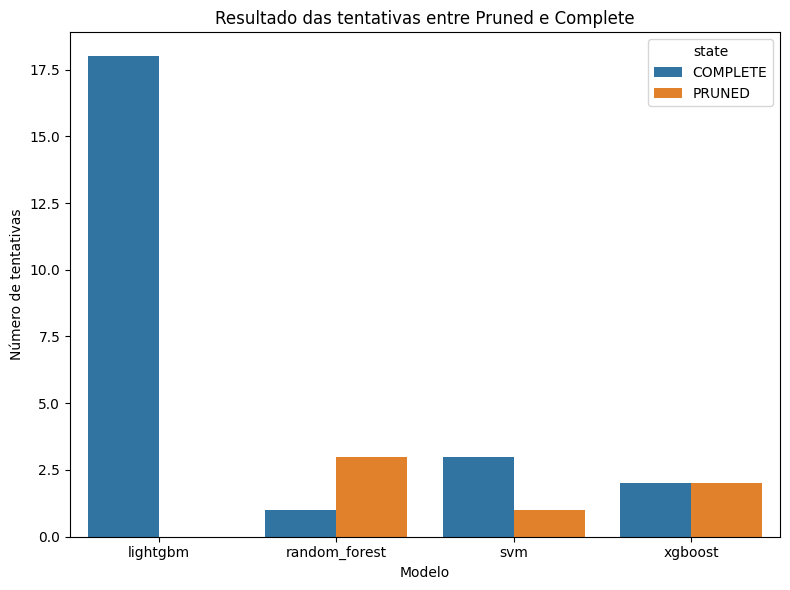

In [38]:
# Gráfico das tentativas de modelos completas e abortadas
counts_state = df_metrics.groupby(["params_model_name", "state"]).size().reset_index(name="count")

plt.figure(figsize=(8, 6))
sns.barplot(data=counts_state,x="params_model_name",y="count",hue="state",)
plt.title("Resultado das tentativas entre Pruned e Complete")
plt.xlabel("Modelo")
plt.ylabel("Número de tentativas")
plt.tight_layout()
plt.show()

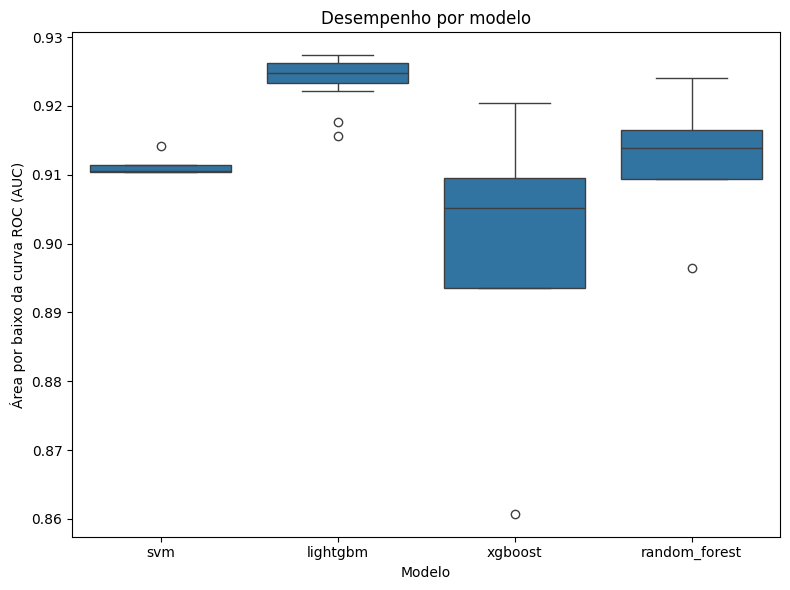

In [39]:
# Distribuição de performance (value) por modelo
plt.figure(figsize=(8, 6))
sns.boxplot(data=df_metrics, x="params_model_name", y="value")
plt.title("Desempenho por modelo")
plt.xlabel("Modelo")
plt.ylabel("Área por baixo da curva ROC (AUC)")
plt.tight_layout()
plt.show()

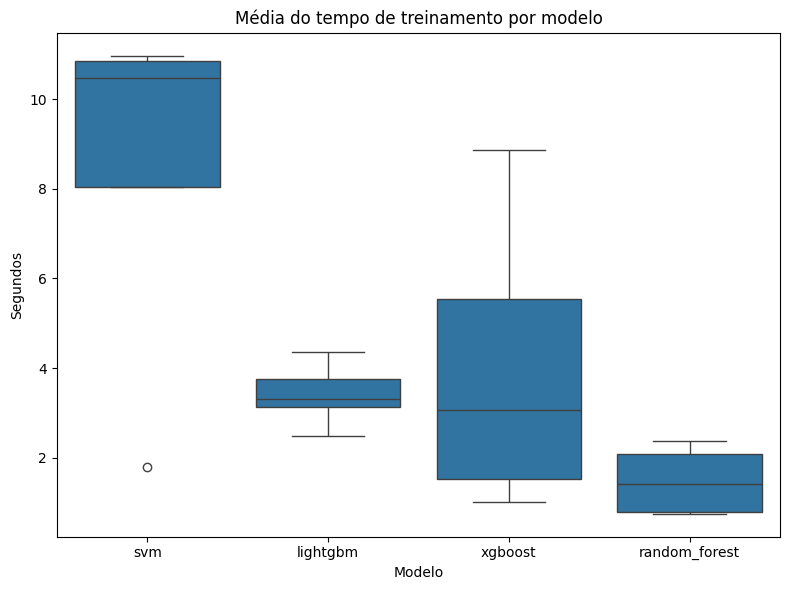

In [40]:
# Duração média de treino por modelo
df_metrics["duration_sec"] = pd.to_timedelta(df_metrics["duration"]).dt.total_seconds()
mean_duration = df_metrics.groupby("params_model_name")["duration_sec"].mean().reset_index()

# Distribuição do tempo de processamento por modelo

plt.figure(figsize=(8, 6))
sns.boxplot(data=df_metrics, x="params_model_name", y="duration_sec")
plt.title("Média do tempo de treinamento por modelo")
plt.xlabel("Modelo")
plt.ylabel("Segundos")
plt.tight_layout()
plt.show()

## Treinamento do modelo final

In [41]:
df_hyper =pd.DataFrame(df_results['hyperparameters'].to_list())
df_hyper

,model_name,n_estimators,learning_rate,max_depth,subsample,colsample_bytree
0,lightgbm,27,0.165026,5,0.787858,0.996118
1,lightgbm,16,0.245605,6,0.851190,0.521619
2,xgboost,22,0.145206,8,0.630703,0.503485
3,lightgbm,14,0.228356,7,0.660814,0.597794
4,lightgbm,26,0.221486,5,0.675340,0.948241


In [42]:
final_params=df_hyper.iloc[:,1:].median().to_dict()
final_params

{'n_estimators': 22.0,
 'learning_rate': 0.221486454257907,
 'max_depth': 6.0,
 'subsample': 0.6753402059985969,
 'colsample_bytree': 0.5977940029474059}

In [43]:
final_params = {'n_estimators': 26,
 'learning_rate': 0.226,
 'max_depth': 7,
 'subsample': 0.662,
 'colsample_bytree': 0.6968}

In [44]:
# Dicionário base para reconstrução
models = {
    'RandomForest': RandomForestClassifier(random_state=42),
    'XGBoost': xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    'LightGBM': lgb.LGBMClassifier(random_state=42),
    'SVM': CalibratedClassifierCV(LinearSVC( random_state=42))
}


In [45]:
# Reconstruir modelo
final_model = models['LightGBM']
final_model.set_params(**final_params)

cat_cols, num_cols = get_feature_types(X_data)

final_pipeline = build_pipeline(final_model, cat_cols, num_cols)

### Avaliando modelo final

In [46]:
# 1. FUNÇÃO PARA EXTRAIR NOMES DAS FEATURES PÓS-OHE
def get_feature_names(column_transformer):
    """
    Extrai nomes finais das features após ColumnTransformer,
    incluindo OneHotEncoder e transformações numéricas.
    """
    output_features = []

    for name, transformer, features in column_transformer.transformers_:

        # Caso 'remainder=passthrough'
        if name == "remainder":
            output_features.extend(features)
            continue

        # Transformers com get_feature_names_out() (OneHotEncoder, etc)
        if hasattr(transformer, "get_feature_names_out"):
            try:
                names = transformer.get_feature_names_out(features)
            except:
                names = transformer.get_feature_names_out()
            output_features.extend(names)

        # Caso não possua o método
        else:
            output_features.extend(features)

    return output_features

# 4. FUNÇÃO FUZZY PARA MATCH COM VARIÁVEIS ORIGINAIS
def fuzzy_match_original(feature_name, triage_features, threshold=70):
    """
    Realiza fuzzy matching buscando qual variável ORIGINAL
    está mais relacionada com o nome da feature pós-OHE.
    """
    best_match, score, _ = process.extractOne(
        feature_name,
        triage_features,
        scorer=fuzz.partial_ratio
    )
    return best_match if score >= threshold else None




  Fold Externo 1/4
[LightGBM] [Info] Number of positive: 4717, number of negative: 4717
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.016650 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 31921
[LightGBM] [Info] Number of data points in the train set: 9434, number of used features: 220
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


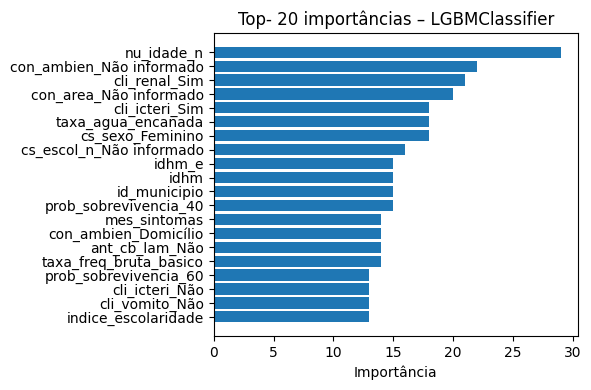

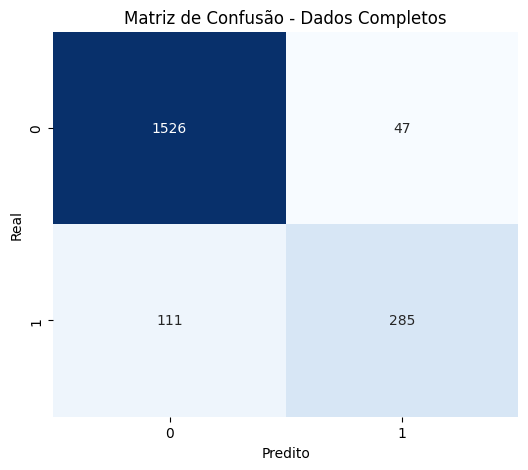

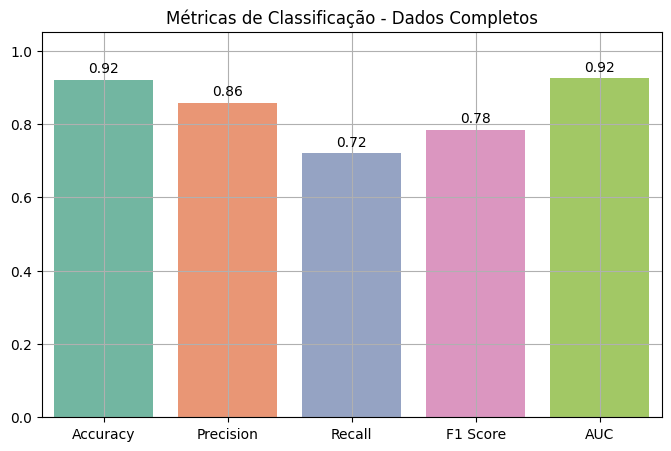

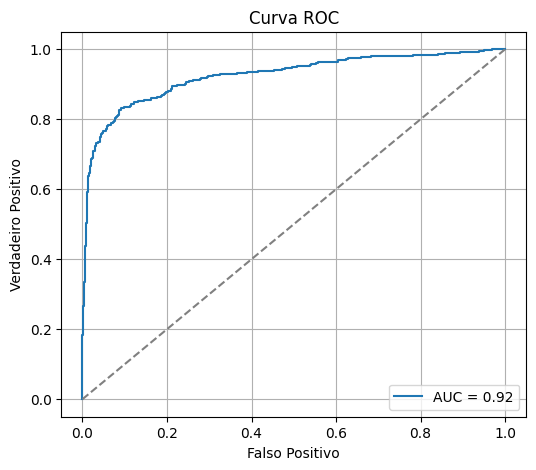

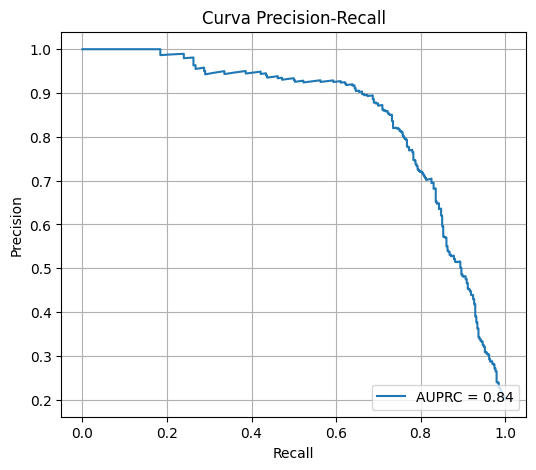

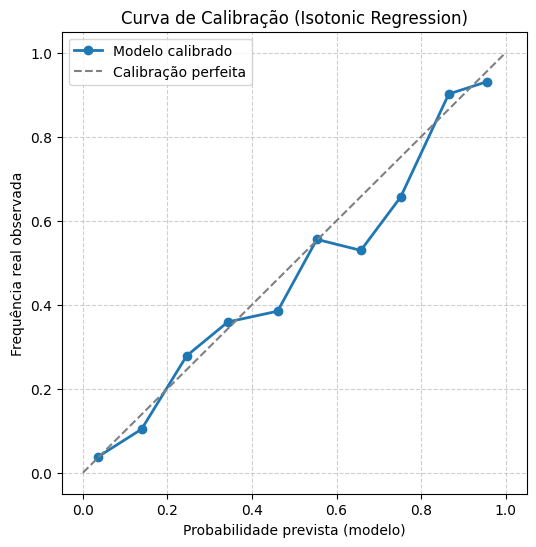

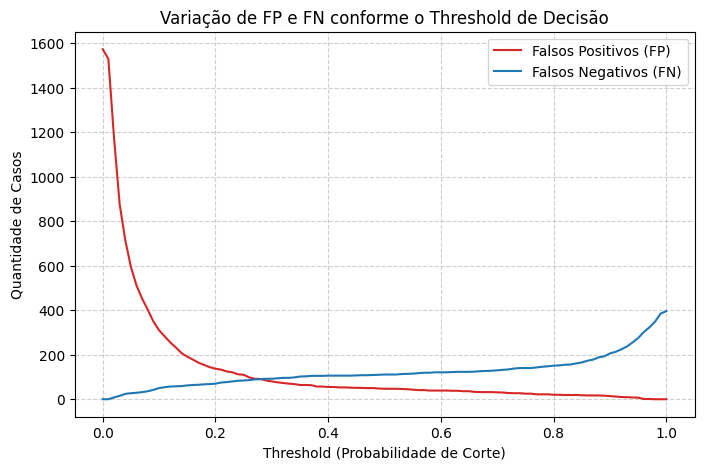


  Fold Externo 1/4
[LightGBM] [Info] Number of positive: 4717, number of negative: 4717
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.016396 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 32121
[LightGBM] [Info] Number of data points in the train set: 9434, number of used features: 216
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


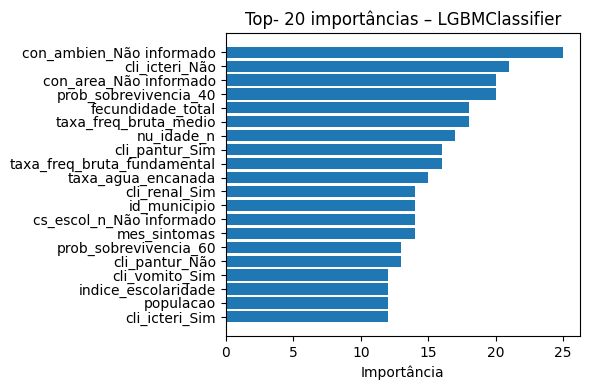

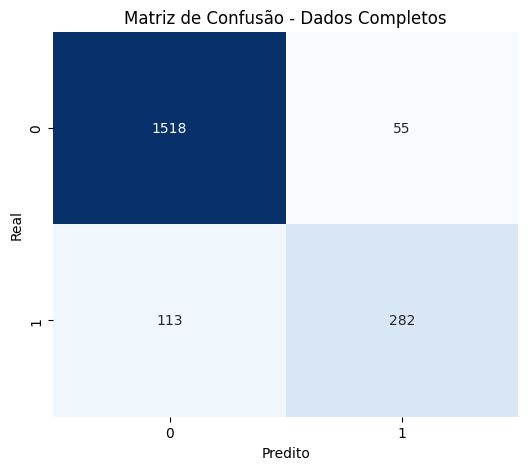

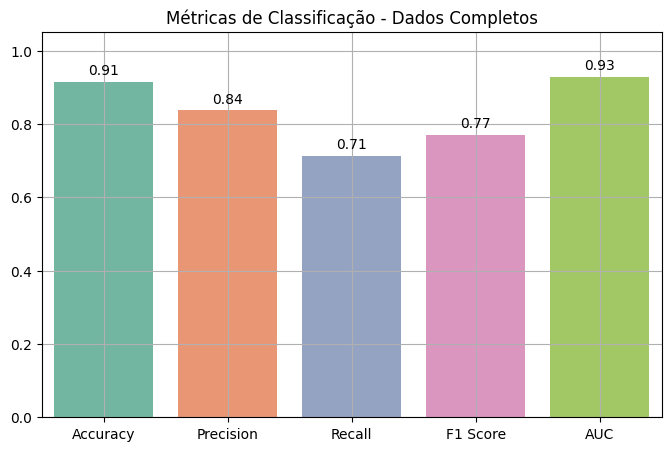

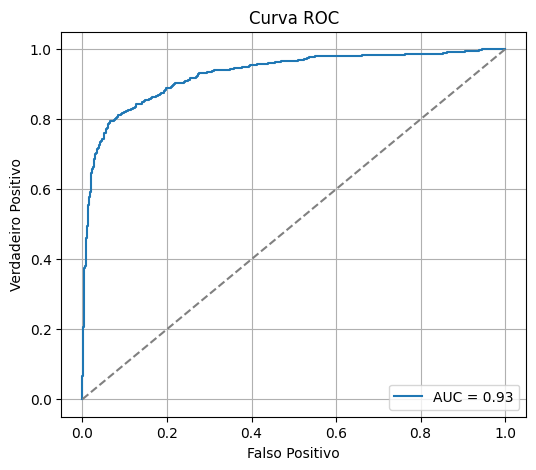

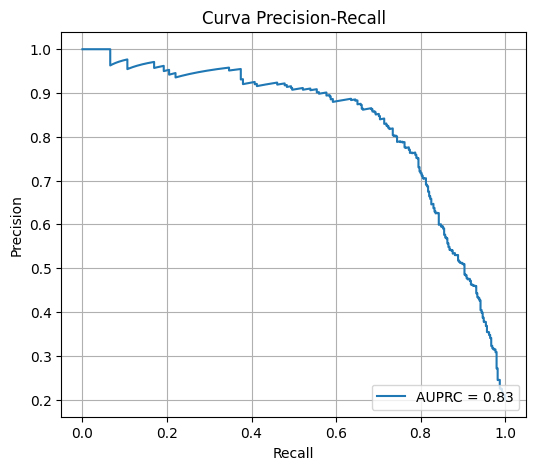

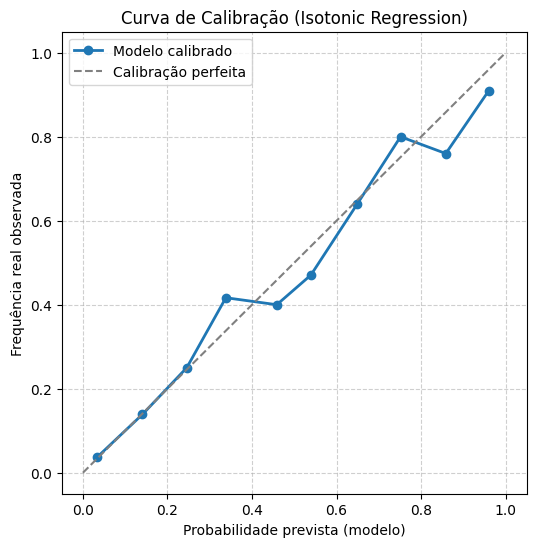

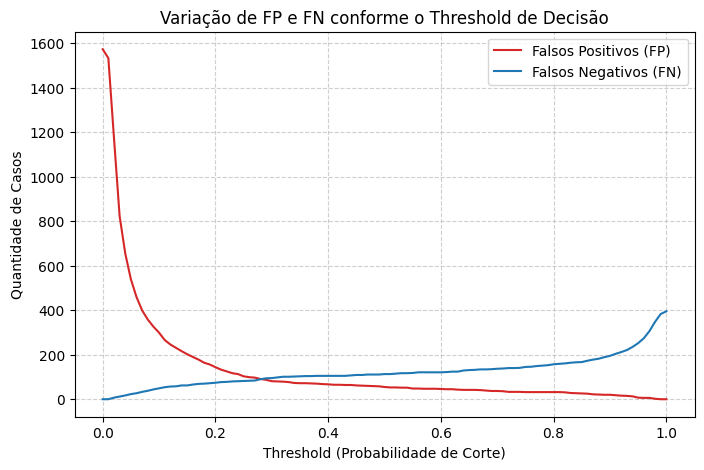


  Fold Externo 1/4
[LightGBM] [Info] Number of positive: 4718, number of negative: 4718
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.035735 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 31926
[LightGBM] [Info] Number of data points in the train set: 9436, number of used features: 210
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


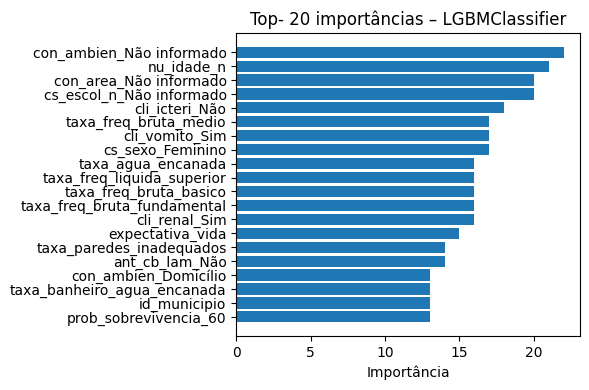

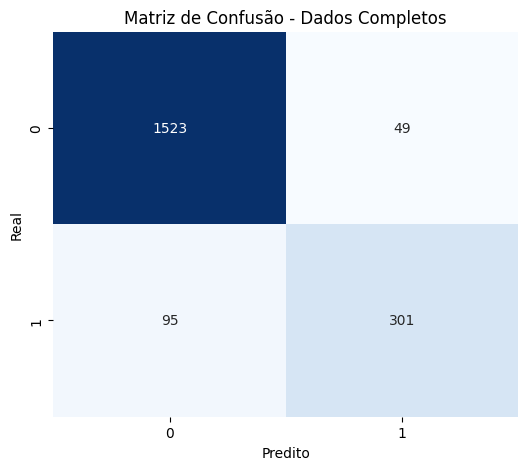

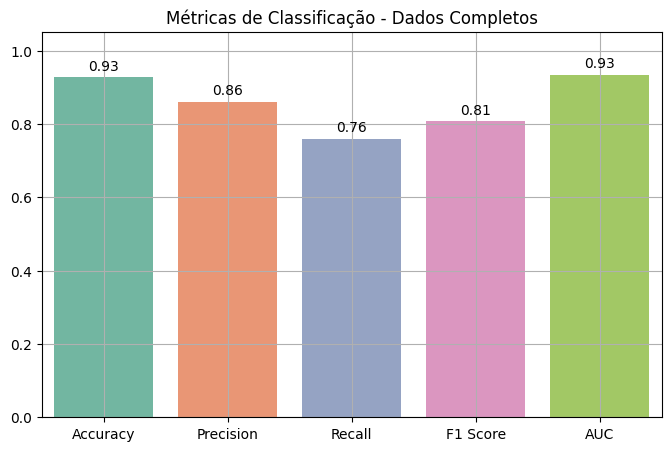

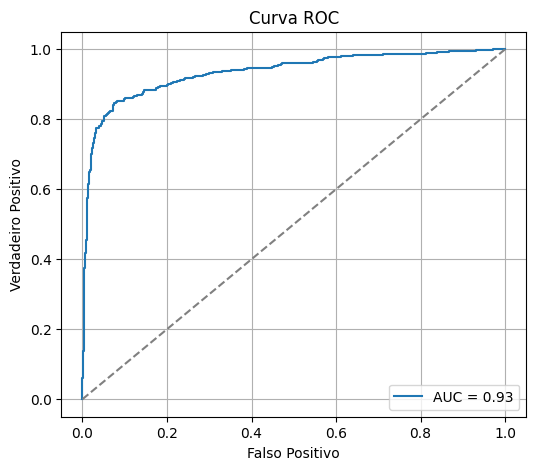

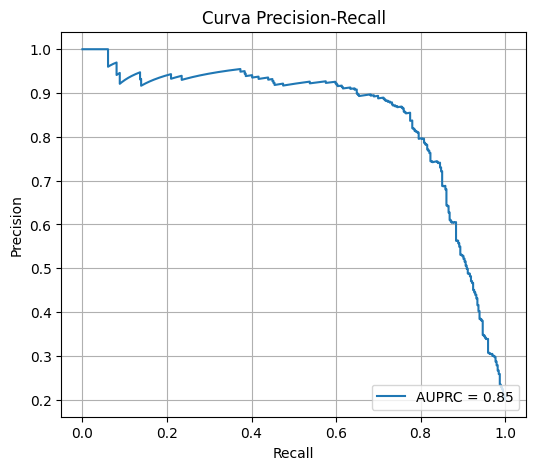

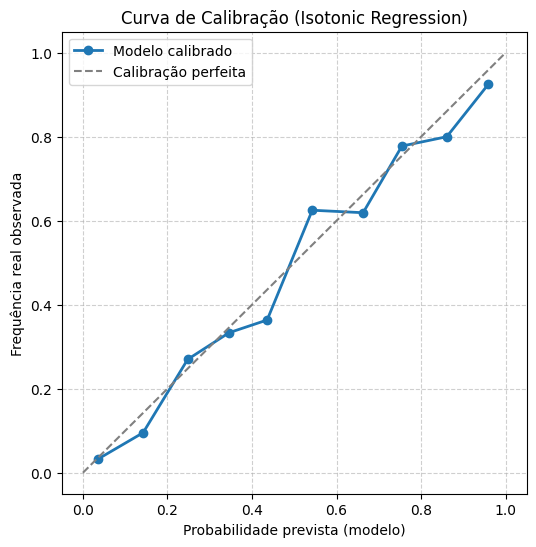

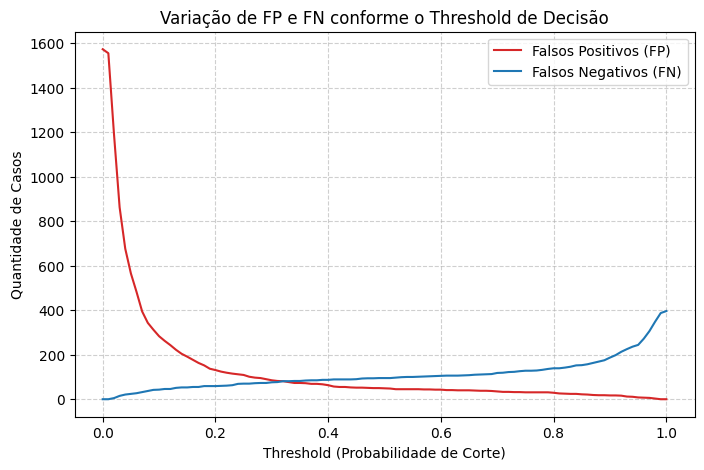


  Fold Externo 1/4
[LightGBM] [Info] Number of positive: 4718, number of negative: 4718
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.016294 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 31978
[LightGBM] [Info] Number of data points in the train set: 9436, number of used features: 213
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


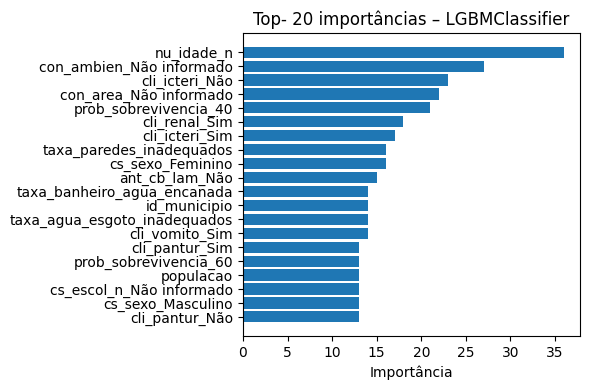

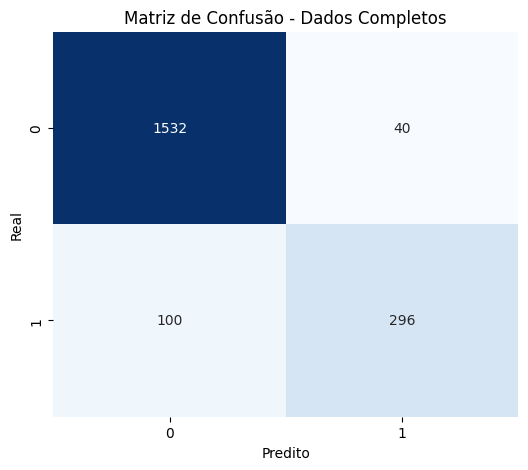

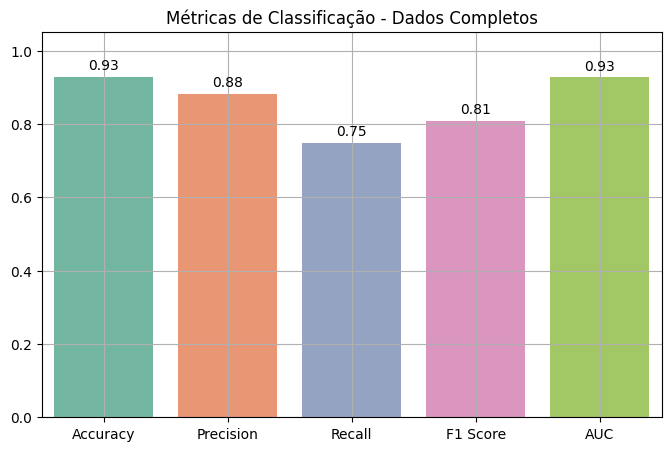

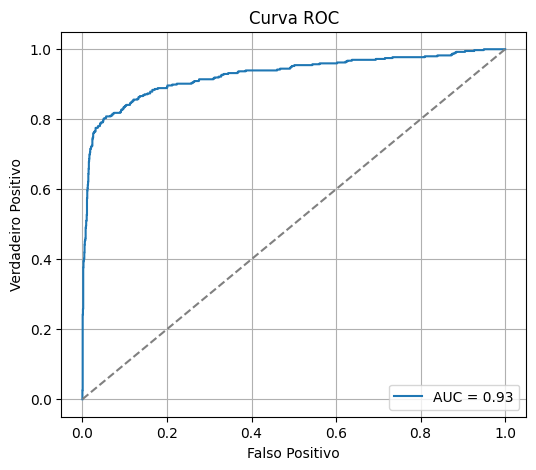

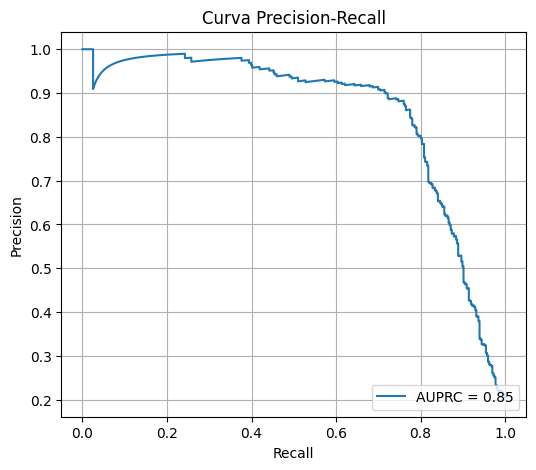

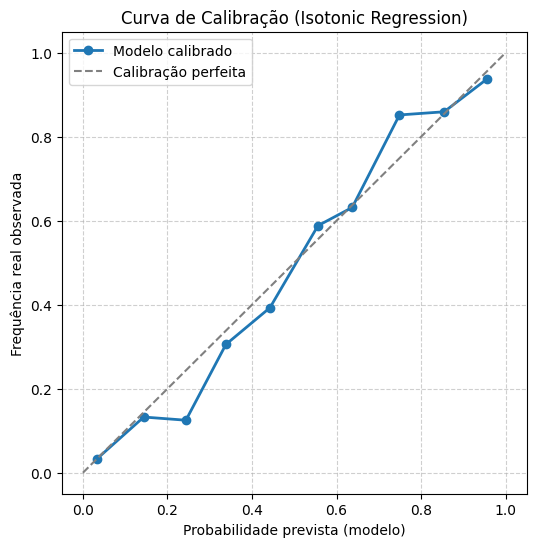

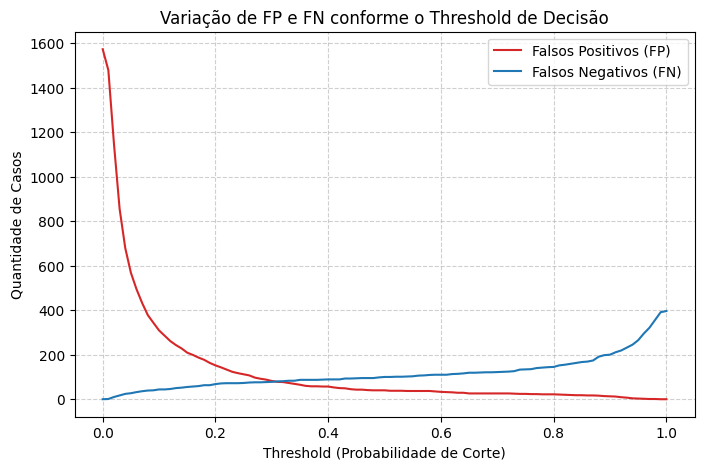

In [47]:
n_splits = 4
outer_cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
results = []
fold = 1
for train_idx, test_idx in outer_cv.split(X_data, y_data):

    print(f"\n==============================")
    print(f"  Fold Externo {fold}/{n_splits}")
    print(f"==============================")

    X_train, X_test = X_data.iloc[train_idx], X_data.iloc[test_idx]
    y_train, y_test = y_data.iloc[train_idx], y_data.iloc[test_idx]

    # Treinando o pipeline final com todo o conjunto de dados
    final_pipeline.fit(X_train,y_train)


    # 1. Recuperar nomes das features após o ColumnTransformer
    preproc  = final_pipeline.named_steps['preprocessor']
    model    = final_pipeline.named_steps['model']
    top_k=20



    # num_features
    num_features = preproc.transformers_[0][2]

    # cat_features (expandidos pelo OneHot)
    cat_encoder      = preproc.named_transformers_['cat'].get_feature_names_out()

    cat_features_raw  = preproc.transformers_[1][2]
    cat_feature_names = preproc.named_transformers_["cat"].get_feature_names_out(cat_features_raw)

    feature_names = np.concatenate([num_features, cat_feature_names])

    # 2. Extrair importâncias
    if hasattr(model, "feature_importances_"):
        # RandomForest, XGBClassifier, LGBMClassifier
        importances = model.feature_importances_

    elif isinstance(model, SVC) and model.kernel == "linear":
        # |coef_| para SVM linear
        importances = np.abs(model.coef_).flatten()

    else:
        # Qualquer modelo sem atributo nativo → permutação
        perm = permutation_importance(
            final_pipeline, X_val, y_val,
            n_repeats=10, scoring="roc_auc",
            n_jobs=-1, random_state=42
        )
        importances = perm.importances_mean

    # 3. Organizar e selecionar as k variáveis mais relevantes
    imp_df = (pd.DataFrame({"feature": feature_names,
                            "importance": importances})
                .sort_values("importance", ascending=False)
                .head(top_k))

    #Plotando o gráfico
    plt.figure(figsize=(6, 4))
    plt.barh(imp_df["feature"][::-1],
            imp_df["importance"][::-1])
    plt.xlabel("Importância")
    plt.title(f"Top- {top_k} importâncias – {type(model).__name__}")
    plt.tight_layout()
    plt.show()



    # Gerar previsões finais
    y_pred = final_pipeline.predict(X_test)
    y_proba = final_pipeline.predict_proba(X_test)[:, 1] if hasattr(final_model, "predict_proba") else None

    # Matriz de confusão
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title("Matriz de Confusão - Dados Completos")
    plt.xlabel("Predito")
    plt.ylabel("Real")
    plt.show()

    # Barplot com métricas
    metrics_dict = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "AUC": roc_auc_score(y_test, y_proba) if y_proba is not None else np.nan
    }

    plt.figure(figsize=(8, 5))
    sns.barplot(x=list(metrics_dict.keys()), y=list(metrics_dict.values()), palette="Set2")
    plt.ylim(0, 1.05)
    plt.title("Métricas de Classificação - Dados Completos")
    for i, v in enumerate(metrics_dict.values()):
        plt.text(i, v + 0.02, f"{v:.2f}", ha='center')
    plt.grid(True)
    plt.show()

    # Curva ROC
    if y_proba is not None:
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        roc_auc = auc(fpr, tpr)

        plt.figure(figsize=(6, 5))
        plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
        plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
        plt.xlabel("Falso Positivo")
        plt.ylabel("Verdadeiro Positivo")
        plt.title("Curva ROC")
        plt.legend(loc='lower right')
        plt.grid(True)
        plt.show()

    # Curva Precision-Recall
    if y_proba is not None:
        precision, recall, _ = precision_recall_curve(y_test, y_proba)
        auprc_trap = auc(recall, precision)
        plt.figure(figsize=(6, 5))
        plt.plot(recall, precision, label=f"AUPRC = {auprc_trap:.2f}")
        plt.xlabel("Recall")
        plt.ylabel("Precision")
        plt.title("Curva Precision-Recall")
        plt.legend(loc='lower right')
        plt.grid(True)
        plt.show()

    ## Curva de calibração
    if y_proba is not None:

        # --- Calcular curva de calibração ---
        prob_true, prob_pred = calibration_curve(y_test, y_proba, n_bins=10, strategy='uniform')

        # --- Plotar ---
        plt.figure(figsize=(6,6))
        plt.plot(prob_pred, prob_true, marker='o', linewidth=2, label='Modelo calibrado')
        plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Calibração perfeita')
        plt.title("Curva de Calibração (Isotonic Regression)")
        plt.xlabel("Probabilidade prevista (modelo)")
        plt.ylabel("Frequência real observada")
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.show()

    ## Análise de falso positio e falso negativo
    if y_proba is not None:
        # ---  Avaliar FP e FN para thresholds de 0.0 a 1.0 ---
        thresholds = np.linspace(0, 1, 101)
        fp_list, fn_list = [], []

        for t in thresholds:
            y_pred = (y_proba >= t).astype(int)
            tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
            fp_list.append(fp)
            fn_list.append(fn)

        # ---  Montar DataFrame ---
        df_threshold = pd.DataFrame({
            'threshold': thresholds,
            'false_positives': fp_list,
            'false_negatives': fn_list
        })

        # --- Plotar ---
        plt.figure(figsize=(8,5))
        plt.plot(df_threshold['threshold'], df_threshold['false_positives'], label='Falsos Positivos (FP)', color='tab:red')
        plt.plot(df_threshold['threshold'], df_threshold['false_negatives'], label='Falsos Negativos (FN)', color='tab:blue')
        plt.xlabel('Threshold (Probabilidade de Corte)')
        plt.ylabel('Quantidade de Casos')
        plt.title('Variação de FP e FN conforme o Threshold de Decisão')
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.show()



  Fold Externo 1/4
[LightGBM] [Info] Number of positive: 4717, number of negative: 4717
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.038689 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 31921
[LightGBM] [Info] Number of data points in the train set: 9434, number of used features: 220
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


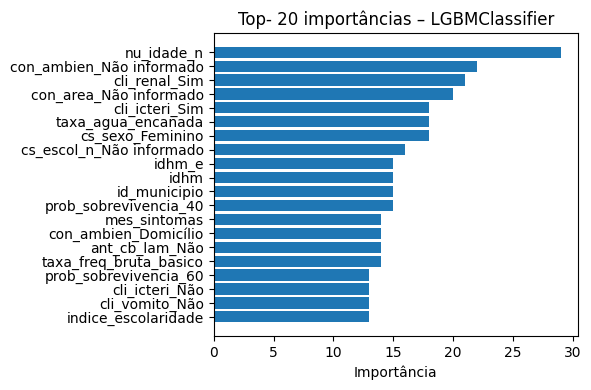

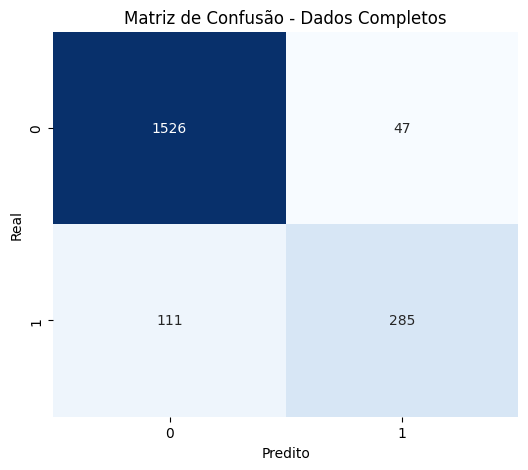

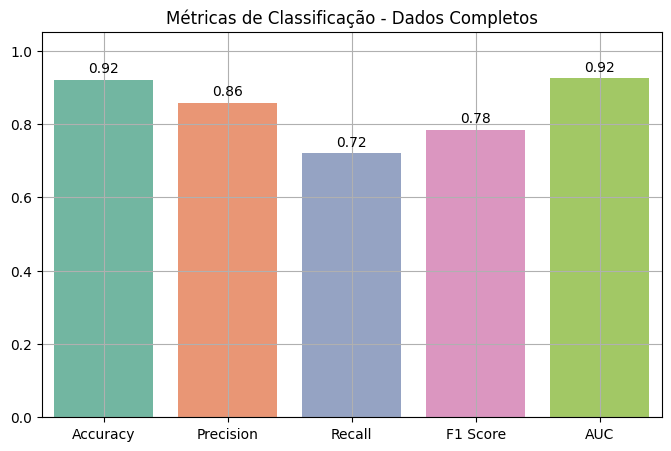

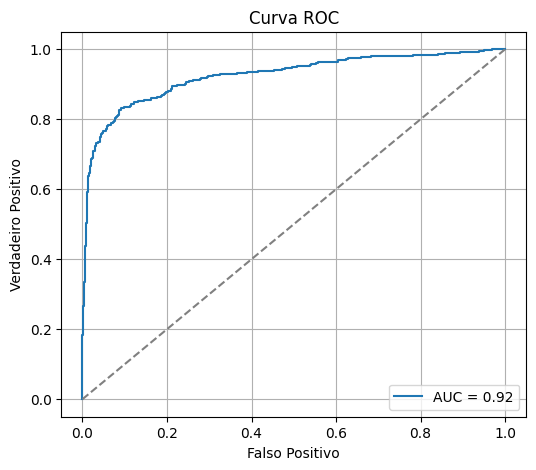

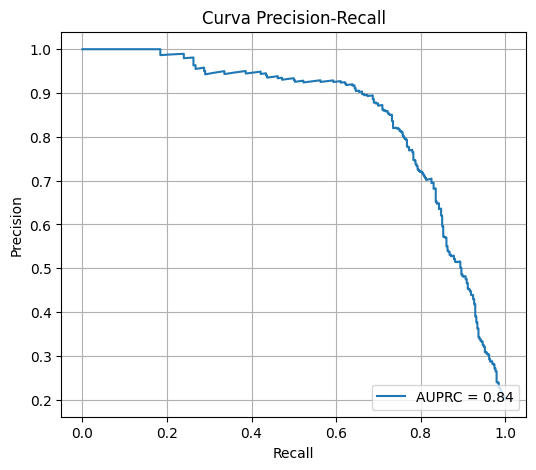

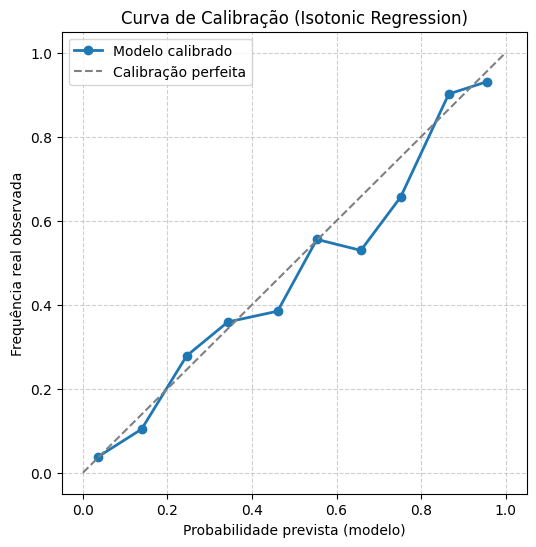

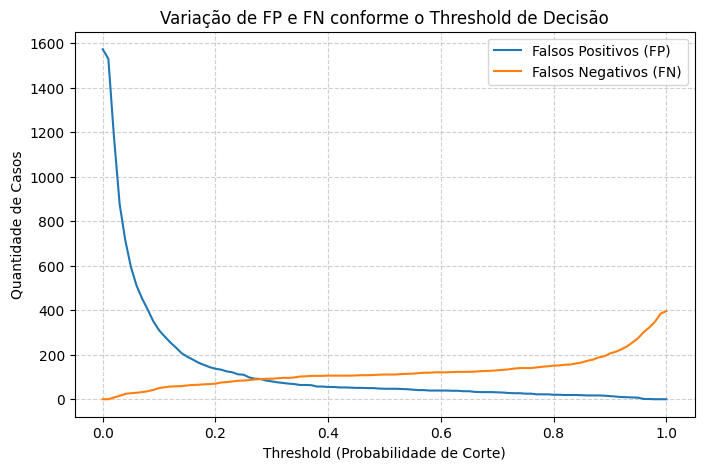


  Fold Externo 2/4
[LightGBM] [Info] Number of positive: 4717, number of negative: 4717
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.052440 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 32121
[LightGBM] [Info] Number of data points in the train set: 9434, number of used features: 216
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


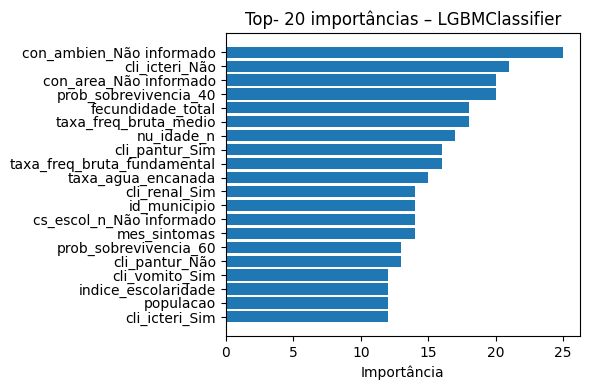

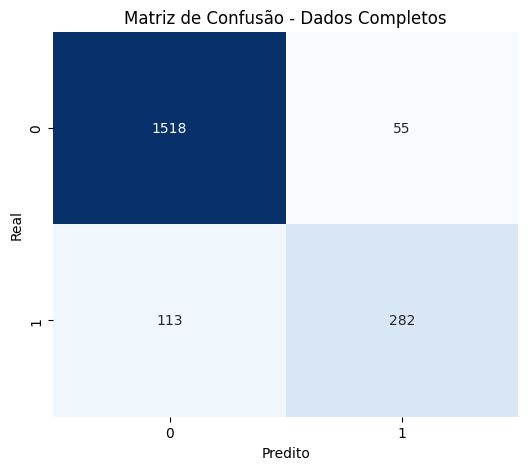

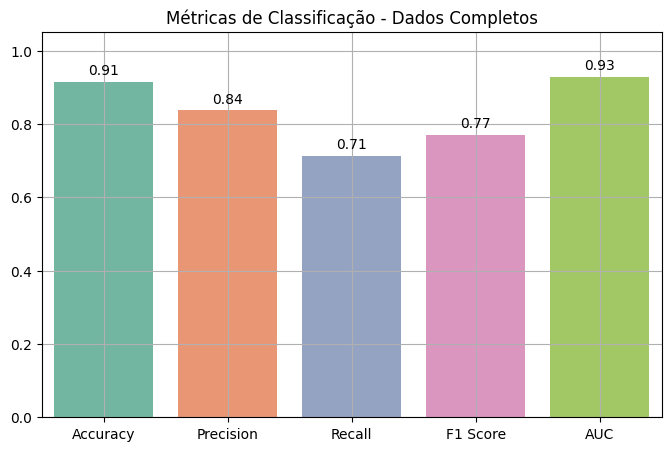

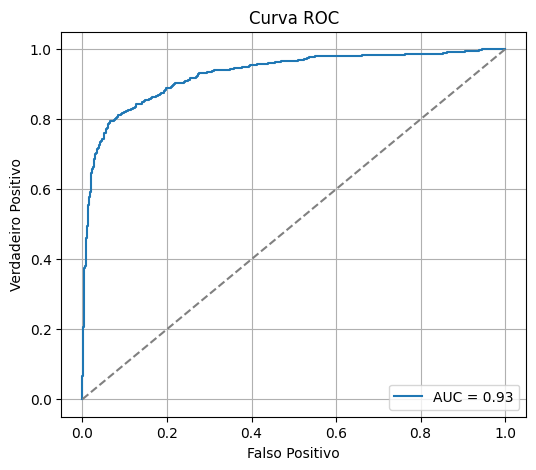

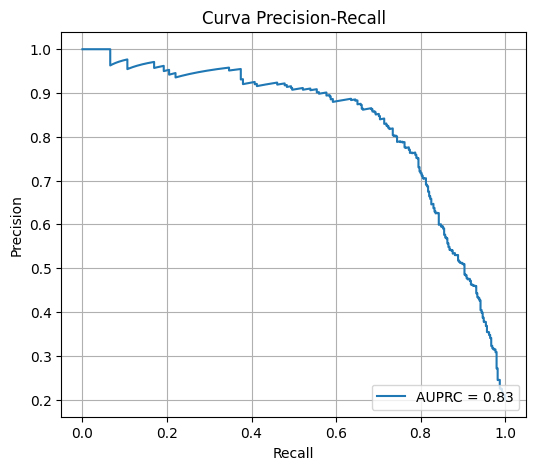

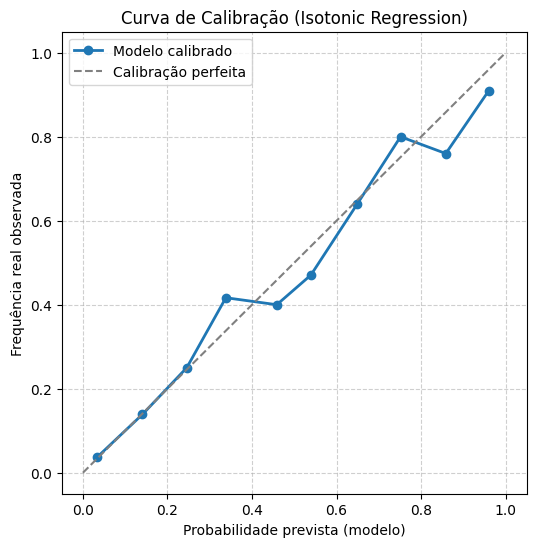

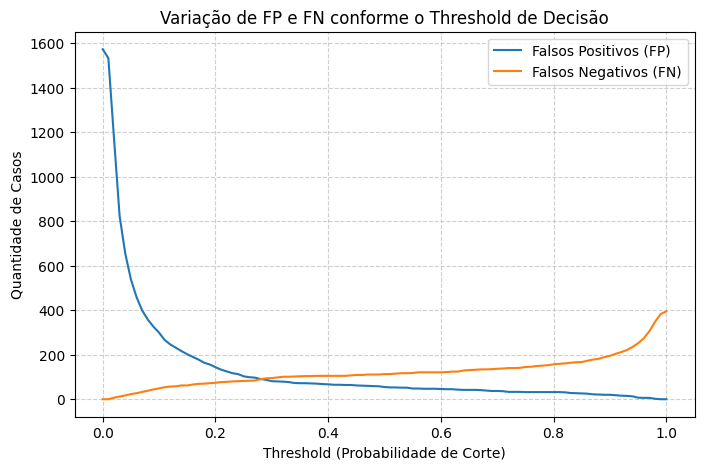


  Fold Externo 3/4
[LightGBM] [Info] Number of positive: 4718, number of negative: 4718
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.016147 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 31926
[LightGBM] [Info] Number of data points in the train set: 9436, number of used features: 210
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


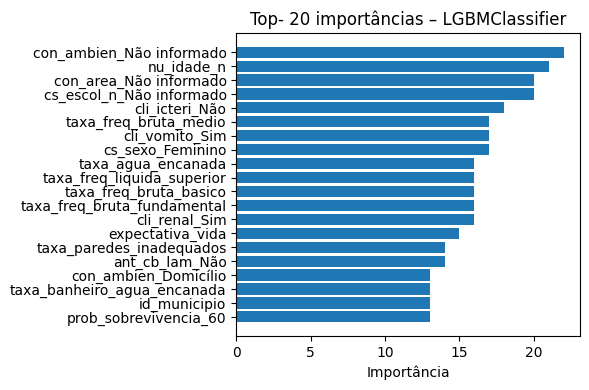

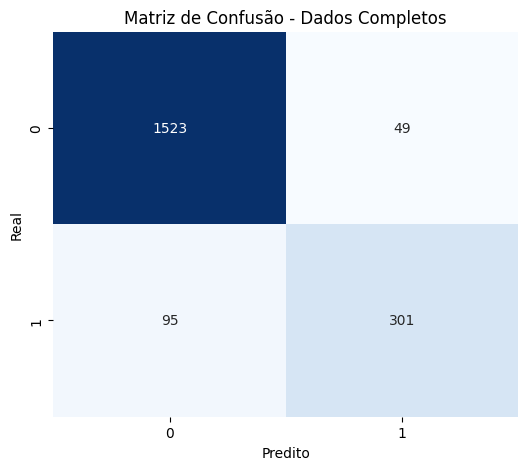

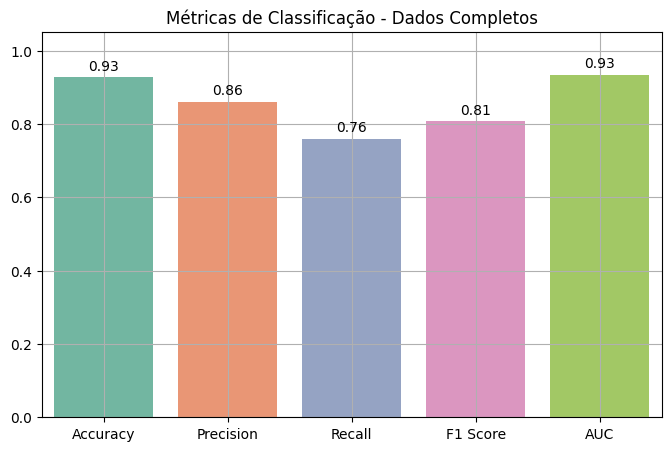

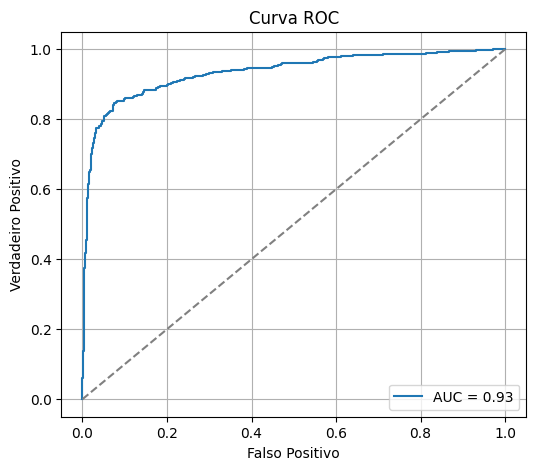

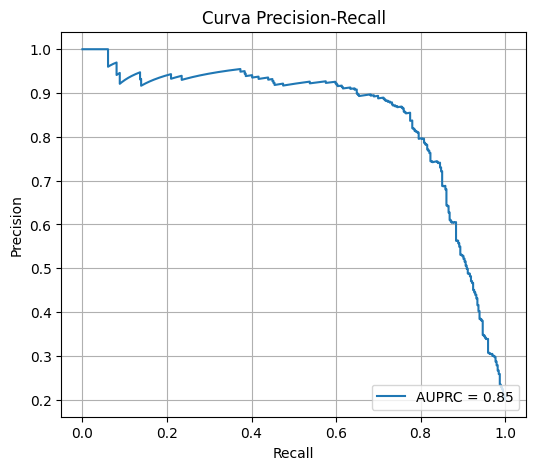

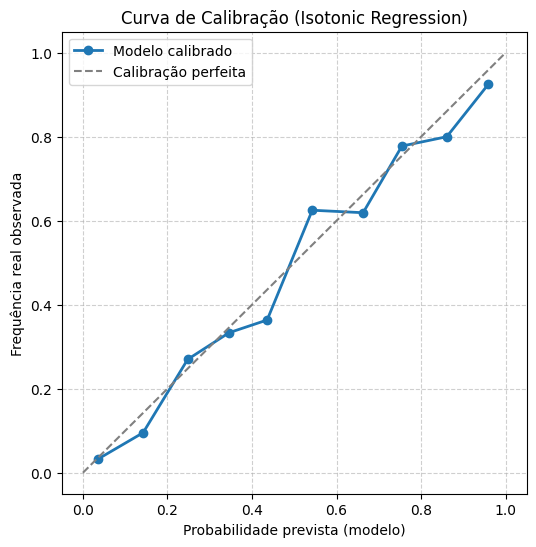

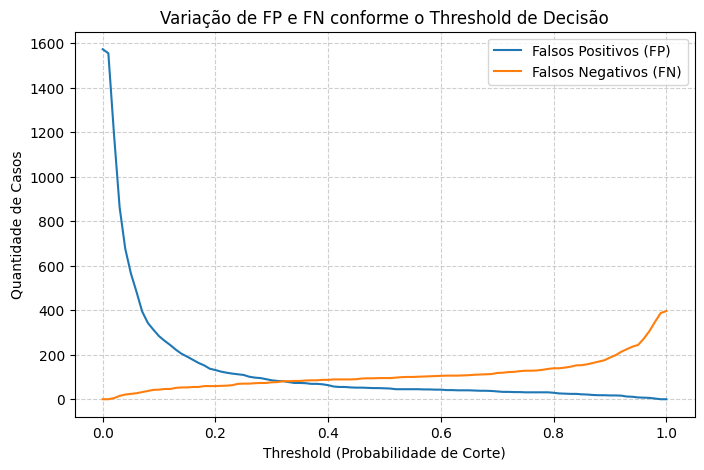


  Fold Externo 4/4
[LightGBM] [Info] Number of positive: 4718, number of negative: 4718
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.016135 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 31978
[LightGBM] [Info] Number of data points in the train set: 9436, number of used features: 213
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


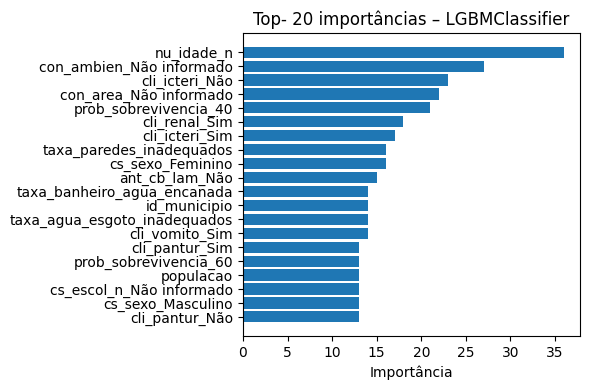

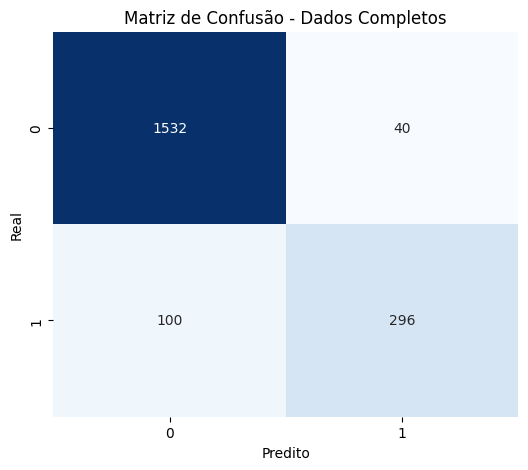

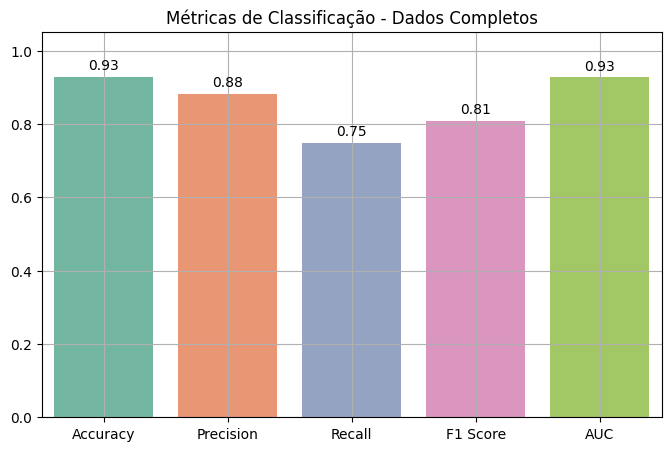

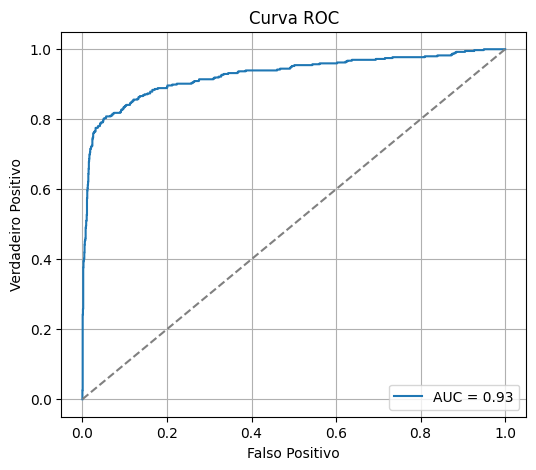

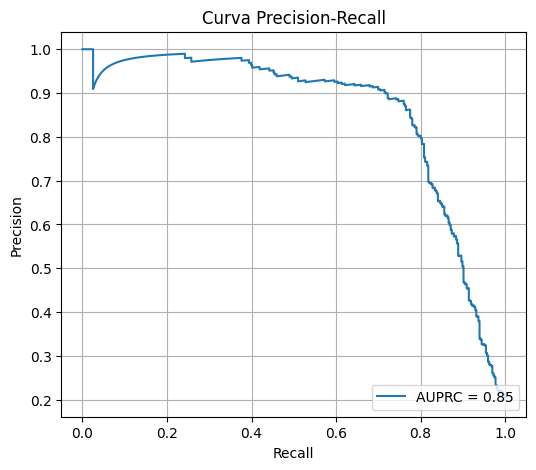

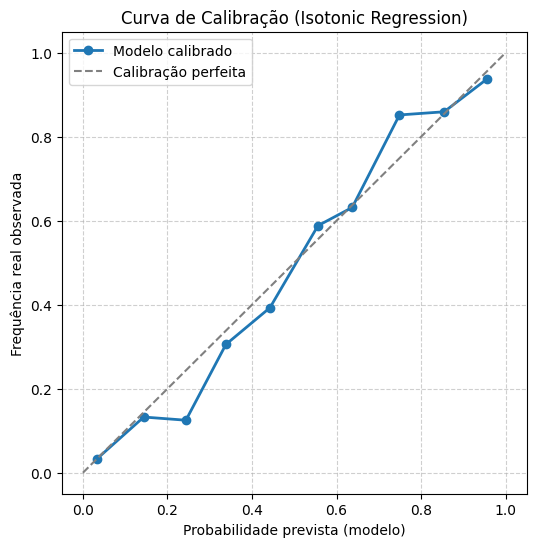

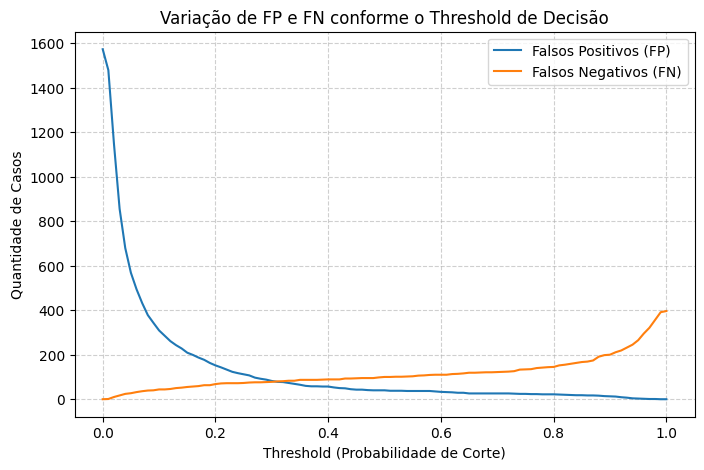


 RESUMO FINAL DAS MÉTRICAS (OUTER CV)

              Média   Mediana  Desvio Padrão
Accuracy   0.922520  0.923293       0.006548
Precision  0.859045  0.859217       0.018039
Recall     0.735299  0.733586       0.022088
F1 Score   0.792293  0.794969       0.018693
AUC        0.928638  0.928075       0.004404


<Figure size 1000x600 with 0 Axes>

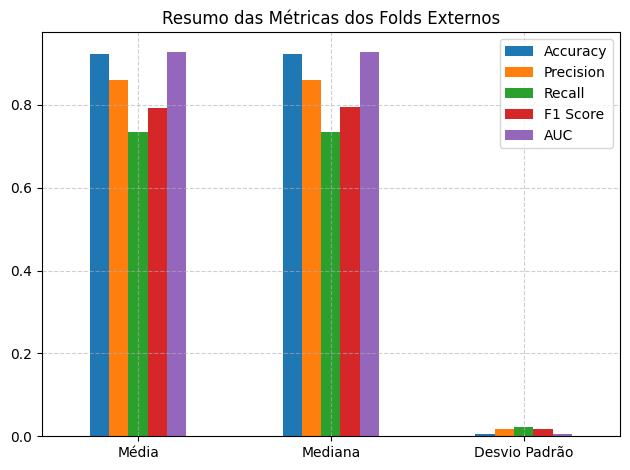

In [48]:
n_splits = 4
outer_cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

results = []
fold = 1

### ADICIONADO — lista para guardar métricas dos folds externos
metrics_all_folds = []

for train_idx, test_idx in outer_cv.split(X_data, y_data):

    print(f"\n==============================")
    print(f"  Fold Externo {fold}/{n_splits}")
    print(f"==============================")

    X_train, X_test = X_data.iloc[train_idx], X_data.iloc[test_idx]
    y_train, y_test = y_data.iloc[train_idx], y_data.iloc[test_idx]

    # Treinando o pipeline final com todo o conjunto de dados
    final_pipeline.fit(X_train,y_train)

    # 1. Recuperar nomes das features após o ColumnTransformer
    preproc  = final_pipeline.named_steps['preprocessor']
    model    = final_pipeline.named_steps['model']
    top_k=20

    num_features = preproc.transformers_[0][2]

    cat_encoder      = preproc.named_transformers_['cat'].get_feature_names_out()
    cat_features_raw  = preproc.transformers_[1][2]
    cat_feature_names = preproc.named_transformers_["cat"].get_feature_names_out(cat_features_raw)

    feature_names = np.concatenate([num_features, cat_feature_names])

    # 2. Extrair importâncias
    if hasattr(model, "feature_importances_"):
        importances = model.feature_importances_
    elif isinstance(model, SVC) and model.kernel == "linear":
        importances = np.abs(model.coef_).flatten()
    else:
        perm = permutation_importance(
            final_pipeline, X_val, y_val,
            n_repeats=10, scoring="roc_auc",
            n_jobs=-1, random_state=42
        )
        importances = perm.importances_mean

    # 3. Importâncias
    imp_df = (pd.DataFrame({"feature": feature_names,
                            "importance": importances})
                .sort_values("importance", ascending=False)
                .head(top_k))

    plt.figure(figsize=(6, 4))
    plt.barh(imp_df["feature"][::-1],
            imp_df["importance"][::-1])
    plt.xlabel("Importância")
    plt.title(f"Top- {top_k} importâncias – {type(model).__name__}")
    plt.tight_layout()
    plt.show()

    # Previsões
    y_pred = final_pipeline.predict(X_test)
    y_proba = final_pipeline.predict_proba(X_test)[:, 1] if hasattr(final_model, "predict_proba") else None

    # Matriz de confusão
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title("Matriz de Confusão - Dados Completos")
    plt.xlabel("Predito")
    plt.ylabel("Real")
    plt.show()

    # Métricas
    metrics_dict = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "AUC": roc_auc_score(y_test, y_proba) if y_proba is not None else np.nan
    }

    ### ADICIONADO — guardar métricas deste fold
    metrics_all_folds.append(metrics_dict)

    plt.figure(figsize=(8, 5))
    sns.barplot(x=list(metrics_dict.keys()), y=list(metrics_dict.values()), palette="Set2")
    plt.ylim(0, 1.05)
    plt.title("Métricas de Classificação - Dados Completos")
    for i, v in enumerate(metrics_dict.values()):
        plt.text(i, v + 0.02, f"{v:.2f}", ha='center')
    plt.grid(True)
    plt.show()

    # Curvas ROC, PR, Calibração e Thresholds (mantido)
    if y_proba is not None:
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        roc_auc = auc(fpr, tpr)
        plt.figure(figsize=(6, 5))
        plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
        plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
        plt.xlabel("Falso Positivo")
        plt.ylabel("Verdadeiro Positivo")
        plt.title("Curva ROC")
        plt.legend(loc='lower right')
        plt.grid(True)
        plt.show()

        precision, recall, _ = precision_recall_curve(y_test, y_proba)
        auprc_trap = auc(recall, precision)
        plt.figure(figsize=(6, 5))
        plt.plot(recall, precision, label=f"AUPRC = {auprc_trap:.2f}")
        plt.xlabel("Recall")
        plt.ylabel("Precision")
        plt.title("Curva Precision-Recall")
        plt.legend(loc='lower right')
        plt.grid(True)
        plt.show()

        prob_true, prob_pred = calibration_curve(y_test, y_proba, n_bins=10, strategy='uniform')

        plt.figure(figsize=(6,6))
        plt.plot(prob_pred, prob_true, marker='o', linewidth=2, label='Modelo calibrado')
        plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Calibração perfeita')
        plt.title("Curva de Calibração (Isotonic Regression)")
        plt.xlabel("Probabilidade prevista (modelo)")
        plt.ylabel("Frequência real observada")
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.show()

        thresholds = np.linspace(0, 1, 101)
        fp_list, fn_list = [], []
        for t in thresholds:
            y_pred_t = (y_proba >= t).astype(int)
            tn, fp, fn, tp = confusion_matrix(y_test, y_pred_t).ravel()
            fp_list.append(fp)
            fn_list.append(fn)

        df_threshold = pd.DataFrame({
            'threshold': thresholds,
            'false_positives': fp_list,
            'false_negatives': fn_list
        })

        plt.figure(figsize=(8,5))
        plt.plot(df_threshold['threshold'], df_threshold['false_positives'], label='Falsos Positivos (FP)')
        plt.plot(df_threshold['threshold'], df_threshold['false_negatives'], label='Falsos Negativos (FN)')
        plt.xlabel('Threshold (Probabilidade de Corte)')
        plt.ylabel('Quantidade de Casos')
        plt.title('Variação de FP e FN conforme o Threshold de Decisão')
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.show()

    fold += 1


# ===============================================
#   RESUMO FINAL DAS MÉTRICAS DOS FOLDS EXTERNOS
# ===============================================
df_metrics = pd.DataFrame(metrics_all_folds)

summary = pd.DataFrame({
    "Média": df_metrics.mean(),
    "Mediana": df_metrics.median(),
    "Desvio Padrão": df_metrics.std()
})

print("\n=====================================")
print(" RESUMO FINAL DAS MÉTRICAS (OUTER CV)")
print("=====================================\n")
print(summary)

# (Opcional) gráfico do resumo
plt.figure(figsize=(10, 6))
summary.T.plot(kind='bar')
plt.title("Resumo das Métricas dos Folds Externos")
plt.xticks(rotation=0)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()
